In [1]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

BASE        = Path("/share/home/e2406751/Superresolution-TIR")
PATCHES_DIR = BASE / "data/processed/patches"
STATS_PATH  = PATCHES_DIR / "stats.json"
PRETRAINED  = BASE / "data/pretrained"

sys.path.insert(0, str(BASE))

with open(STATS_PATH) as f:
    stats = json.load(f)

HR_MEAN    = stats["hr"]["mean"]
HR_STD     = stats["hr"]["std"]
LR_MEAN    = stats["lr"]["mean"]
LR_STD     = stats["lr"]["std"]
DATA_RANGE = stats["hr_data_range"]
DATA_MIN   = stats["hr_percentiles"]["p1"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [24]:
#  Dataset 
from scripts.utils.dataset import SRDataset

val_ds = SRDataset(
    split="val",
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    repeat_channels=True,
    transform=None,
)

# Fix seed ONCE — same tiles used across all plots
np.random.seed(41)
N_SAMPLES = 1
indices   = np.random.choice(len(val_ds), N_SAMPLES, replace=False)
samples   = [val_ds[i] for i in indices]
print(f"Selected tiles: {[s['fname'] for s in samples]}")

Selected tiles: ['PDR_2014_b1_r1280_c256.npy']


In [26]:
# Checkpoints and model names
CKPT_DIR = BASE / "checkpoints/phase2"

CHECKPOINTS = {
    "edsr":       CKPT_DIR / "edsr/edsr_phase2_epoch=41_val_full_psnr=16.8110.ckpt",
    "swinir":     CKPT_DIR / "swinir/swinir_phase2_epoch=12_val_full_psnr=17.1127.ckpt",
    "hat":        CKPT_DIR / "hat/hat_phase2_epoch=16_val_full_psnr=17.2160.ckpt",
    "realesrgan": CKPT_DIR / "realesrgan/realesrgan_phase2_epoch=62_val_full_psnr=15.8215.ckpt",
}

MODEL_NAMES = ["edsr", "swinir", "hat", "realesrgan"]

In [4]:
# Load Phase 1 models (official pretrained)
from scripts.evaluation.eval import build_model

pt_models = {}
for name in MODEL_NAMES:
    pt_models[name] = build_model(
        model_name = name,
        phase      = 1,
        checkpoint = None,
    ).to(device).eval()
    print(f"Loaded PT {name}")

[INFO] Loading EDSR pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/EDSR_baseline_x4.pth
[INFO] Loaded 68/74 layers
Loaded PT edsr


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[INFO] Loading SwinIR pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/SwinIR_classical_x4.pth
[INFO] Loaded 550/550 layers
Loaded PT swinir
[INFO] Fetching HAT arch from GitHub...
[INFO] Loading HAT pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/HAT_imagenet_x4.pth
[INFO] Loaded 864/864 layers
Loaded PT hat
[INFO] Loading RealESRGAN generator: /share/home/e2406751/Superresolution-TIR/data/pretrained/RealESRGAN_generator_x4.pth
[INFO] Generator: loaded 702/702 layers
[INFO] Phase 1 — inference only, no discriminator
Loaded PT realesrgan


In [27]:
# Inference functions 
@torch.no_grad()
def get_sr_pt(model_name, sample):
    """Phase 1 — official pretrained weights, no training."""
    lr  = sample["lr"].unsqueeze(0).to(device)
    sr  = pt_models[model_name](lr)
    return (sr[:, 0:1] * HR_STD + HR_MEAN).squeeze().cpu().numpy()


def get_sr_ft(model_name, sample):
    """Phase 2 — our fine-tuned checkpoint."""
    common = dict(hr_mean=HR_MEAN, hr_std=HR_STD,
                  data_range=DATA_RANGE, data_min=DATA_MIN, phase=2)

    if model_name == "edsr":
        from scripts.models.edsr import EDSRModule
        model = EDSRModule.load_from_checkpoint(
            CHECKPOINTS[model_name], **common)
    elif model_name == "swinir":
        from scripts.models.swinir import SwinIRModule
        model = SwinIRModule.load_from_checkpoint(
            CHECKPOINTS[model_name], **common)
    elif model_name == "hat":
        from scripts.models.hat import HATModule
        model = HATModule.load_from_checkpoint(
            CHECKPOINTS[model_name], **common)
    elif model_name == "realesrgan":
        from scripts.models.realesrgan import RealESRGANModule
        model = RealESRGANModule.load_from_checkpoint(
            CHECKPOINTS[model_name], **common)

    model.eval().cuda()
    with torch.no_grad():
        lr = sample["lr"].unsqueeze(0).cuda()
        sr = model(lr)
    sr_celsius = (sr[:, 0:1] * HR_STD + HR_MEAN).squeeze().cpu().numpy()
    del model
    torch.cuda.empty_cache()
    return sr_celsius


def prep_sample(sample):
    hr_mask = sample["hr_mask"].squeeze().numpy()
    lr_64   = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_256  = np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1)
    lr_np   = np.where(hr_mask > 0.5, lr_256, np.nan)
    hr_np   = sample["hr"][0].numpy() * HR_STD + HR_MEAN
    hr_np   = np.where(hr_mask > 0.5, hr_np, np.nan)

    valid = hr_np[hr_mask > 0.5]

    # BEFORE: vmin, vmax = np.nanmin(valid), np.nanmax(valid)
    # AFTER: use percentiles to stop outlier pixels dominating the scale
    vmin = np.nanpercentile(valid, 1)
    vmax = np.nanpercentile(valid, 99)

    return lr_np, hr_np, hr_mask, vmin, vmax

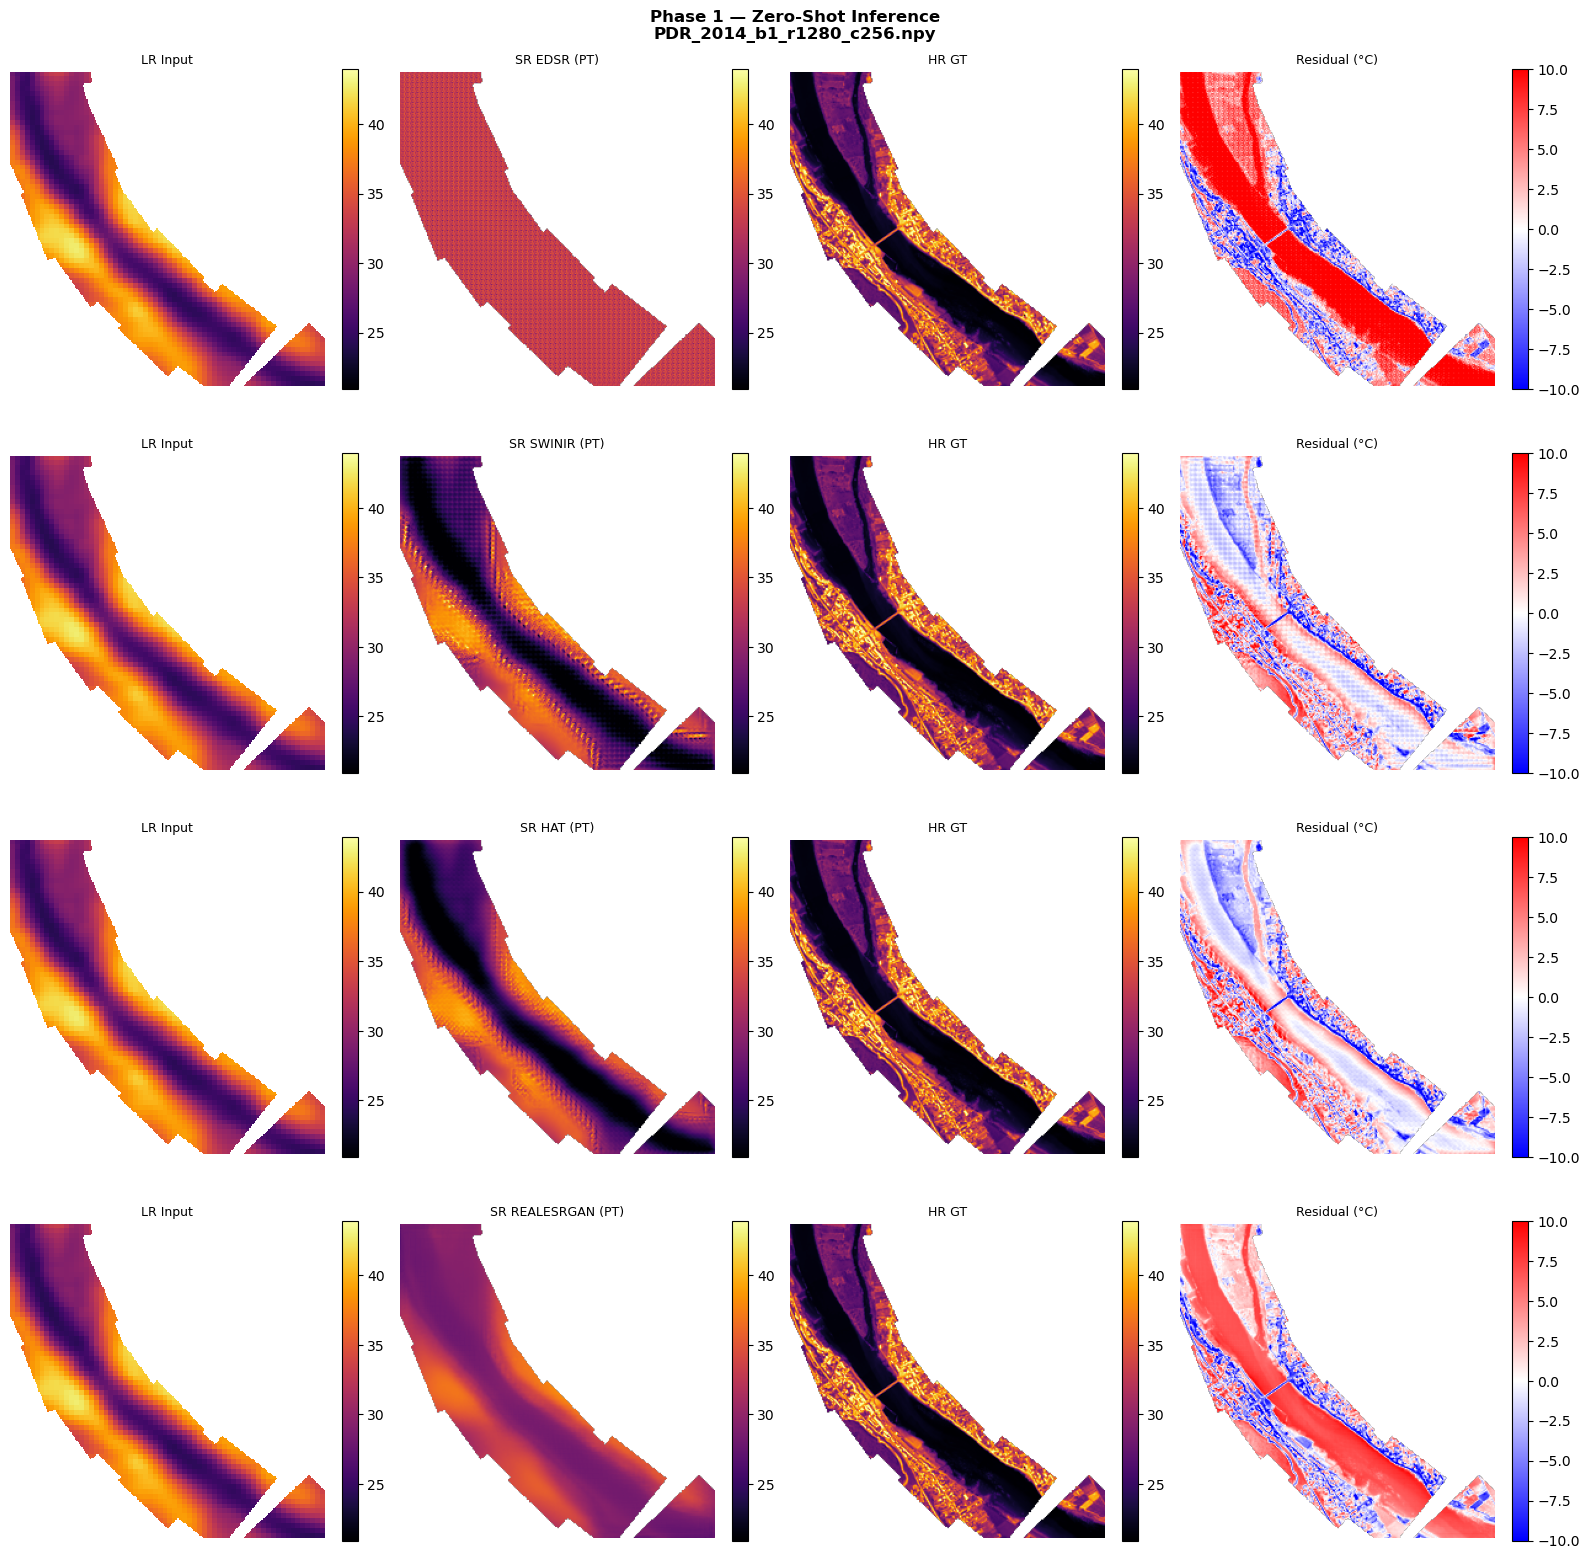

In [25]:
#  Plot Phase 1 inference
# Columns: LR | SR | HR | Residual
for s_idx, sample in enumerate(samples):
    fname = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    fig, axes = plt.subplots(len(MODEL_NAMES), 4,
                             figsize=(16, 4 * len(MODEL_NAMES)))
    fig.suptitle(f"Phase 1 — Zero-Shot Inference\n{fname}",
                 fontsize=12, fontweight="bold")

    for m_idx, model_name in enumerate(MODEL_NAMES):
        sr_np    = get_sr_pt(model_name, sample)
        sr_np    = np.where(hr_mask > 0.5, sr_np, np.nan)
        residual = np.where(hr_mask > 0.5, sr_np - hr_np, np.nan)
        res_lim  = min(np.nanmax(np.abs(residual[hr_mask > 0.5])), 10) \
                   if np.isfinite(residual).any() else 5

        im = axes[m_idx, 0].imshow(lr_np, cmap="inferno", vmin=vmin, vmax=vmax, interpolation="nearest")
        axes[m_idx, 0].set_title("LR Input", fontsize=9)
        axes[m_idx, 0].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 0], fraction=0.046)

        im = axes[m_idx, 1].imshow(sr_np, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 1].set_title(f"SR {model_name.upper()} (PT)", fontsize=9)
        axes[m_idx, 1].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 1], fraction=0.046)

        im = axes[m_idx, 2].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 2].set_title("HR GT", fontsize=9)
        axes[m_idx, 2].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 2], fraction=0.046)

        im = axes[m_idx, 3].imshow(residual, cmap="bwr",
                                   vmin=-res_lim, vmax=res_lim)
        axes[m_idx, 3].set_title(f"Residual (°C)", fontsize=9)
        axes[m_idx, 3].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 3], fraction=0.046)

    plt.tight_layout()
    plt.show()

/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


[INFO] Loading EDSR pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/EDSR_baseline_x4.pth
[INFO] Loaded 68/74 layers
[INFO] Loading SwinIR pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/SwinIR_classical_x4.pth
[INFO] Loaded 550/550 layers
[INFO] Loading HAT pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/HAT_imagenet_x4.pth
[INFO] Loaded 864/864 layers
[INFO] Loading RealESRGAN generator: /share/home/e2406751/Superresolution-TIR/data/pretrained/RealESRGAN_generator_x4.pth
[INFO] Generator: loaded 702/702 layers
[INFO] Loading RealESRGAN discriminator: /share/home/e2406751/Superresolution-TIR/data/pretrained/RealESRGAN_discriminator_x4.pth
[INFO] Discriminator: loaded 28/28 layers


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[INFO] Phase 2 — GAN training enabled


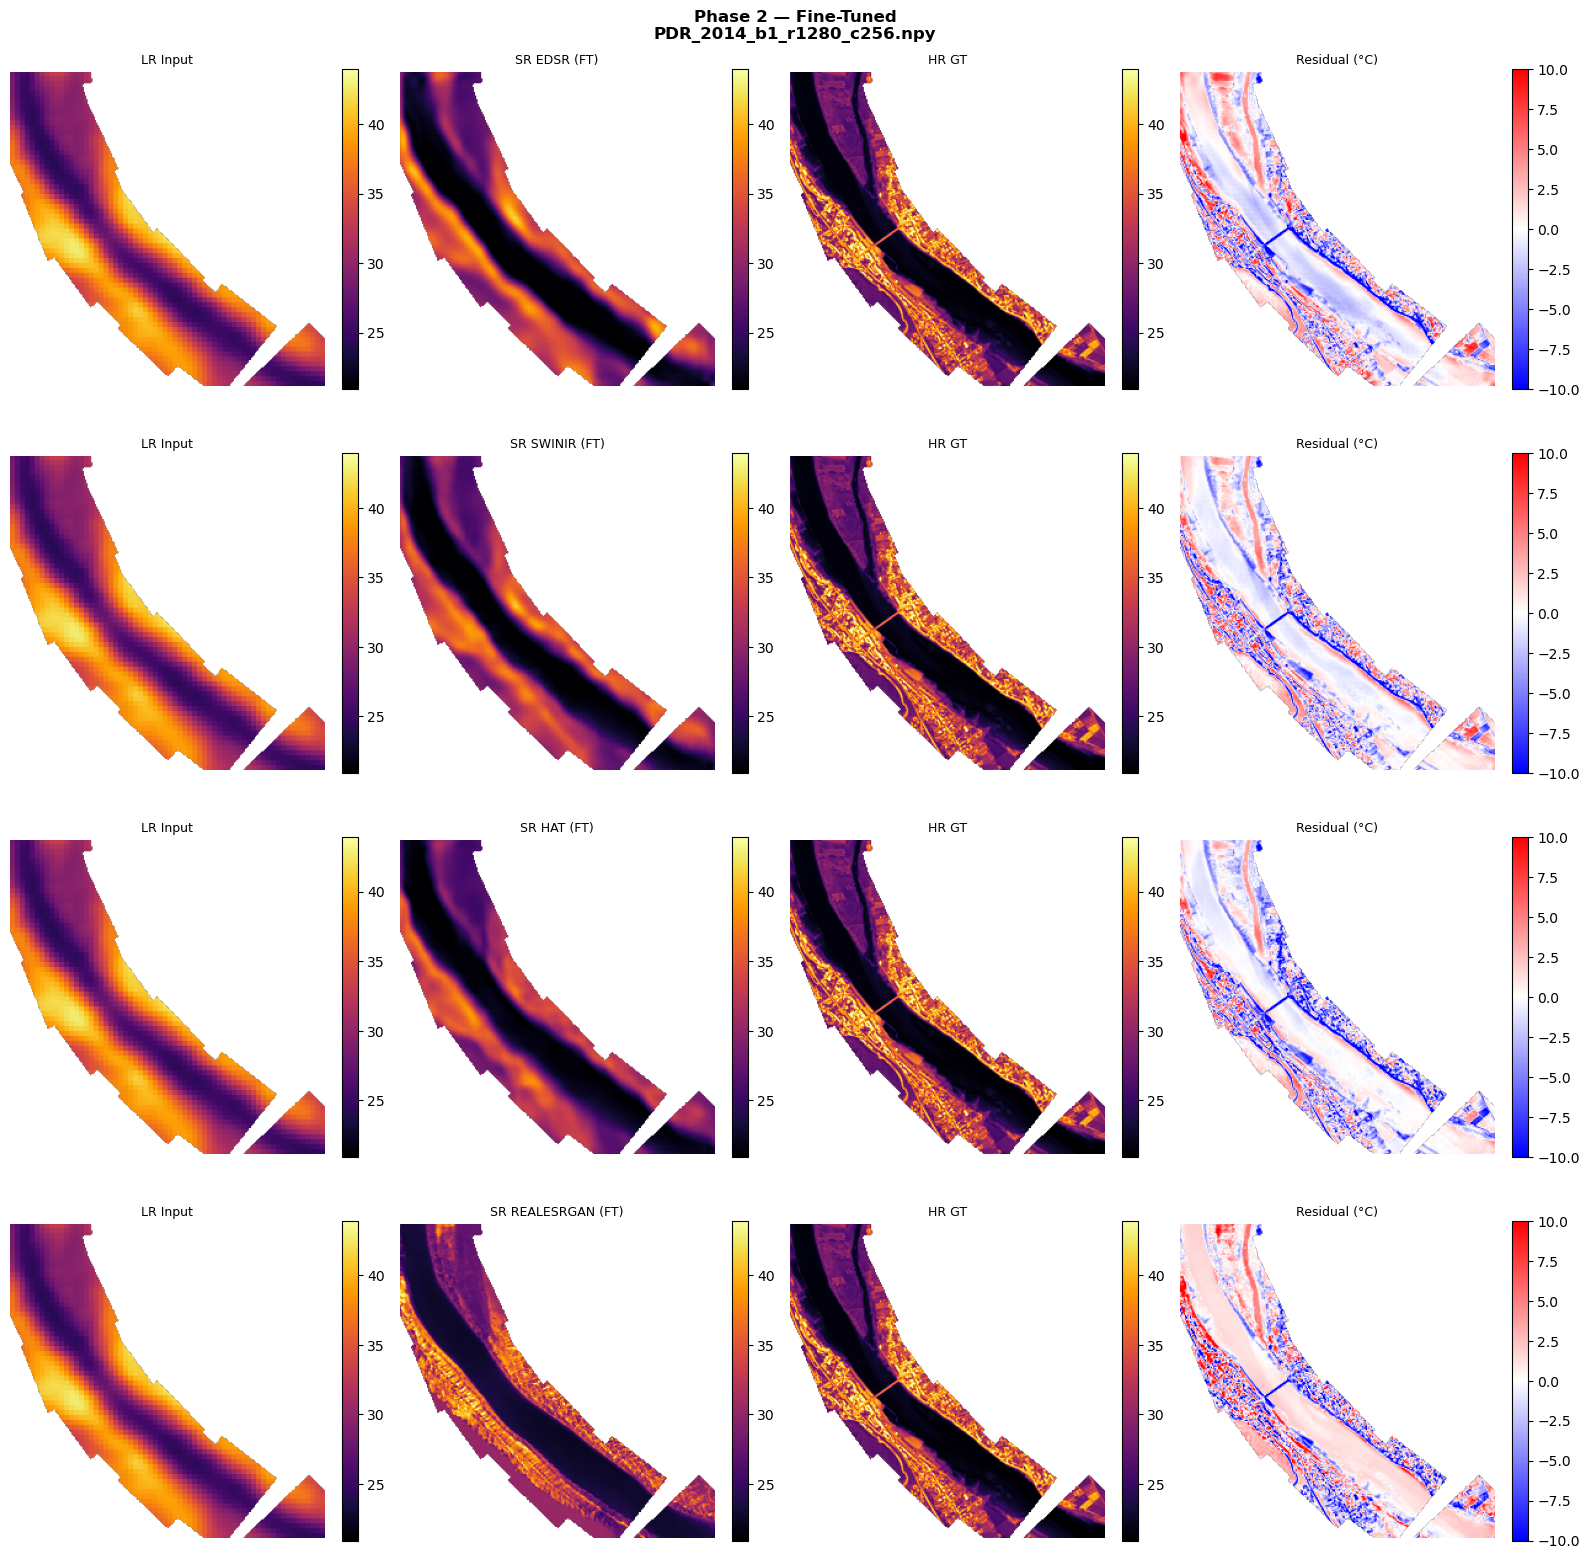

In [28]:
# Plot Phase 2 fine-tuned
# Columns: LR | SR | HR | Residual
for s_idx, sample in enumerate(samples):
    fname = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    fig, axes = plt.subplots(len(MODEL_NAMES), 4,
                             figsize=(16, 4 * len(MODEL_NAMES)))
    fig.suptitle(f"Phase 2 — Fine-Tuned\n{fname}",
                 fontsize=12, fontweight="bold")

    for m_idx, model_name in enumerate(MODEL_NAMES):
        sr_np    = get_sr_ft(model_name, sample)
        sr_np    = np.where(hr_mask > 0.5, sr_np, np.nan)
        residual = np.where(hr_mask > 0.5, sr_np - hr_np, np.nan)
        res_lim  = min(np.nanmax(np.abs(residual[hr_mask > 0.5])), 10) \
                   if np.isfinite(residual).any() else 5

        im = axes[m_idx, 0].imshow(lr_np, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 0].set_title("LR Input", fontsize=9)
        axes[m_idx, 0].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 0], fraction=0.046)

        im = axes[m_idx, 1].imshow(sr_np, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 1].set_title(f"SR {model_name.upper()} (FT)", fontsize=9)
        axes[m_idx, 1].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 1], fraction=0.046)

        im = axes[m_idx, 2].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 2].set_title("HR GT", fontsize=9)
        axes[m_idx, 2].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 2], fraction=0.046)

        im = axes[m_idx, 3].imshow(residual, cmap="bwr",
                                   vmin=-res_lim, vmax=res_lim)
        axes[m_idx, 3].set_title(f"Residual (°C)", fontsize=9)
        axes[m_idx, 3].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 3], fraction=0.046)

    plt.tight_layout()
    plt.show()

[INFO] Loading EDSR pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/EDSR_baseline_x4.pth
[INFO] Loaded 68/74 layers


[INFO] Loading SwinIR pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/SwinIR_classical_x4.pth
[INFO] Loaded 550/550 layers
[INFO] Loading HAT pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/HAT_imagenet_x4.pth
[INFO] Loaded 864/864 layers
[INFO] Loading RealESRGAN generator: /share/home/e2406751/Superresolution-TIR/data/pretrained/RealESRGAN_generator_x4.pth
[INFO] Generator: loaded 702/702 layers
[INFO] Loading RealESRGAN discriminator: /share/home/e2406751/Superresolution-TIR/data/pretrained/RealESRGAN_discriminator_x4.pth
[INFO] Discriminator: loaded 28/28 layers
[INFO] Phase 2 — GAN training enabled


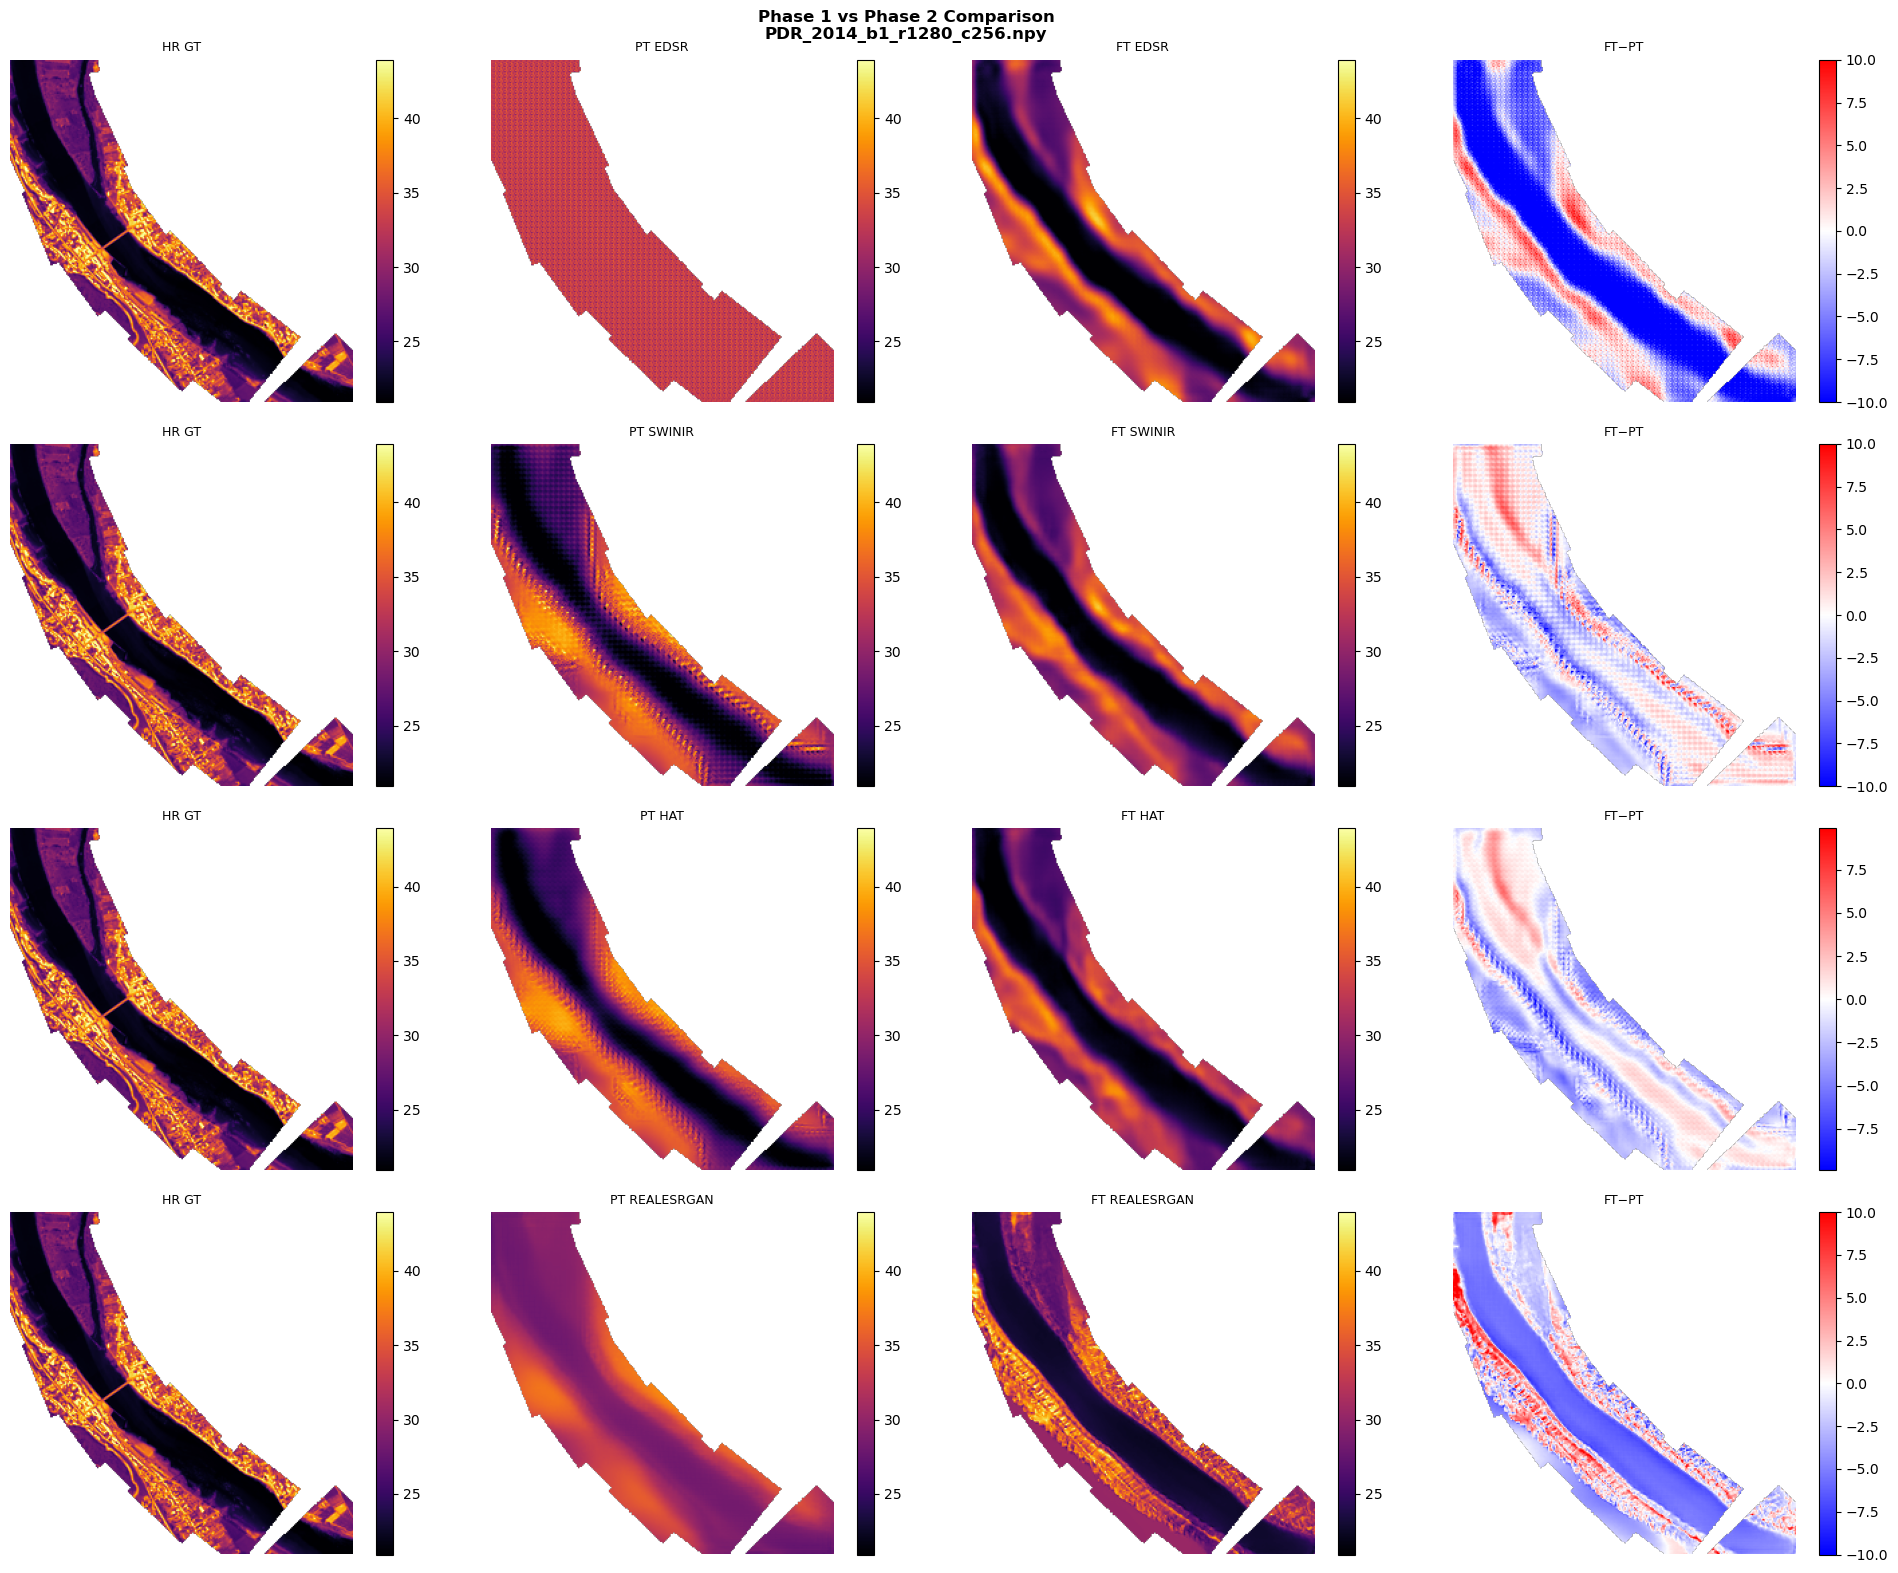

In [29]:
# Plot PT vs FT comparison
# Columns: PT SR | FT SR | HR GT | FT-PT diff | Improvement
for s_idx, sample in enumerate(samples):
    fname = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    fig, axes = plt.subplots(len(MODEL_NAMES), 4,
                             figsize=(20, 4 * len(MODEL_NAMES)))
    fig.suptitle(f"Phase 1 vs Phase 2 Comparison\n{fname}",
                 fontsize=12, fontweight="bold")

    for m_idx, model_name in enumerate(MODEL_NAMES):
        # Get both predictions
        sr_pt = get_sr_pt(model_name, sample)
        sr_ft = get_sr_ft(model_name, sample)

        sr_pt = np.where(hr_mask > 0.5, sr_pt, np.nan)
        sr_ft = np.where(hr_mask > 0.5, sr_ft, np.nan)

        # Error maps
        err_pt = np.where(hr_mask > 0.5, sr_pt - hr_np, np.nan)
        err_ft = np.where(hr_mask > 0.5, sr_ft - hr_np, np.nan)

        # FT - PT prediction difference
        diff = np.where(hr_mask > 0.5, sr_ft - sr_pt, np.nan)

        # Improvement: positive = FT better, negative = PT better
        improvement = np.where(
            hr_mask > 0.5,
            np.abs(err_pt) - np.abs(err_ft),
            np.nan
        )

        valid_mask = hr_mask > 0.5
        res_lim  = min(np.nanmax(np.abs(err_ft[valid_mask])), 10) \
                   if np.isfinite(err_ft).any() else 5
        diff_lim = min(np.nanmax(np.abs(diff[valid_mask])), 10) \
                   if np.isfinite(diff).any() else 5
        imp_lim  = min(np.nanmax(np.abs(improvement[valid_mask])), 10) \
                   if np.isfinite(improvement).any() else 5

        # Col 0 — HR GT
        im = axes[m_idx, 0].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 0].set_title("HR GT", fontsize=9)
        axes[m_idx, 0].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 0], fraction=0.046)

        # Col 1 — Phase 1 SR
        im = axes[m_idx, 1].imshow(sr_pt, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 1].set_title(f"PT {model_name.upper()}", fontsize=9)
        axes[m_idx, 1].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 1], fraction=0.046)

        # Col 2 — Phase 2 SR
        im = axes[m_idx, 2].imshow(sr_ft, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 2].set_title(f"FT {model_name.upper()}", fontsize=9)
        axes[m_idx, 2].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 2], fraction=0.046)

        # Col 3 — FT minus PT (prediction difference)
        im = axes[m_idx, 3].imshow(diff, cmap="bwr",
                                   vmin=-diff_lim, vmax=diff_lim)
        axes[m_idx, 3].set_title(f"FT−PT", fontsize=9)
        axes[m_idx, 3].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 3], fraction=0.046)


    plt.tight_layout()
    plt.show()